In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
file_path = "/content/Sales Forecasting_Train Data.xlsx"

data = pd.read_excel(file_path)
data.head()


,HQ,Country,State_of_outlet,City_of_outlet,Month,Day,Year,Total_Sales
0,Asia,India,NaN,Bombay (Mumbai),1,1,2005,72.2
1,Asia,India,NaN,Bombay (Mumbai),1,2,2005,72.7
2,Asia,India,NaN,Bombay (Mumbai),1,3,2005,74.3
3,Asia,India,NaN,Bombay (Mumbai),1,4,2005,78.9
4,Asia,India,NaN,Bombay (Mumbai),1,5,2005,81.5


In [4]:
data.columns


Index(['HQ', 'Country', 'State_of_outlet', 'City_of_outlet', 'Month', 'Day',
       'Year', 'Total_Sales'],
      dtype='object')

In [6]:
sales_data = data[['Total_Sales']]

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_sales = scaler.fit_transform(sales_data)


In [8]:
def create_sequences(dataset, time_step=10):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_sequences(scaled_sales, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)


In [9]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [10]:
model = Sequential()
model.add(Input(shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))


In [11]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0222
Epoch 2/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0028
Epoch 3/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0025
Epoch 4/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0022
Epoch 5/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0027
Epoch 6/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0018
Epoch 7/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0026
Epoch 8/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0018
Epoch 9/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0027
Epoch 10/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0023
Epoch 11/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0027
Epoch 12/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0025
Epoch 13/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0028
Epoch 14/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0023
Epoch 15/30
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/st

In [13]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [14]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)


Train RMSE: 10.418109647602787
Test RMSE: 14.593506505679354


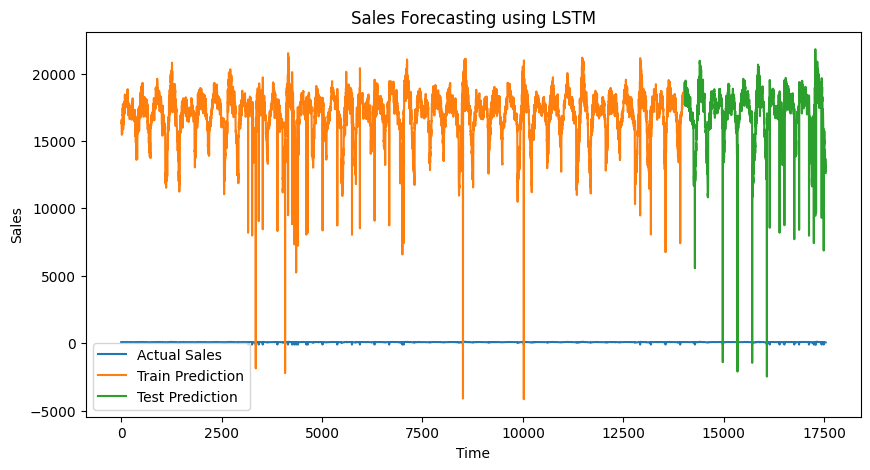

In [15]:
plt.figure(figsize=(10,5))
plt.plot(sales_data.values, label="Actual Sales")

train_plot = np.empty_like(scaled_sales)
train_plot[:] = np.nan
train_plot[time_step:train_size + time_step] = train_predict

test_plot = np.empty_like(scaled_sales)
test_plot[:] = np.nan
test_plot[train_size + time_step:] = test_predict

plt.plot(scaler.inverse_transform(train_plot), label="Train Prediction")
plt.plot(scaler.inverse_transform(test_plot), label="Test Prediction")

plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Sales Forecasting using LSTM")
plt.legend()
plt.show()
